# **Course Title:** Data Analysis & Business Modeling Lab
### **Assignment Title:** Modeling and Optimizing Real-World Organizational Problems Using Linear Programming, Network Optimization, and Applied Data Analytics

## Step-0: Setting Up

In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Step-1: Asking Questions

Based on clinical history (e.g, `hypertension`, `heart disease`, `avg_glucose_level`), meta-physical characteristics (e.g., `age`, `bmi`, `gender`) and external drivers (e.g., `smoking_status`, `work_type`, `ever_married`, `Residence_type`) determine the possibility of stroke of a particular person.  
So, it is a **Classification** Problem

## Step-2: Data Gathering

##### *DataSet link:* [Stroke Prediction Dataset - kaggle](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

In [5]:
current_directory = os.getcwd()

dataset_path = os.path.join(os.path.dirname(current_directory), 'Datasets')

stroke = pd.read_csv(f"{dataset_path}\\healthcare-dataset-stroke-data.csv")

In [6]:
stroke.sample(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1978,21724,Female,42.0,0,0,Yes,Self-employed,Urban,124.34,34.7,formerly smoked,0
3283,247,Male,31.0,0,0,No,Private,Urban,72.60,31.6,never smoked,0
173,2182,Female,80.0,1,0,Yes,Self-employed,Rural,91.02,32.9,formerly smoked,1
1333,58101,Female,56.0,0,1,Yes,Private,Rural,64.66,26.7,formerly smoked,0
3072,10826,Female,39.0,0,0,Yes,Self-employed,Urban,82.85,22.9,smokes,0
796,64732,Female,29.0,0,0,No,Private,Urban,60.26,20.4,never smoked,0
3341,51762,Female,59.0,0,0,Yes,Private,Rural,134.24,28.8,Unknown,0
2104,66680,Female,49.0,1,0,Yes,Private,Rural,65.34,39.4,never smoked,0
1193,70678,Female,55.0,0,1,No,Private,Rural,109.69,22.2,smokes,0
3644,8719,Male,12.0,0,0,No,children,Urban,116.25,16.4,formerly smoked,0


## Step-3: Data Assessing

### 3a. Understand the Data (Context)

#### i. Manual Observation (Observe on Excel Sheet)

In [7]:
# Save the DataFrame to an Excel file
with pd.ExcelWriter(f"{dataset_path}\\healthcare-dataset-stroke-data.xlsx") as write:
    stroke.to_excel(write, sheet_name="stroke", index=False)

#### ii. Programmatic Observation

In [71]:
stroke.shape

(5110, 12)

In [69]:
min_male_age, min_female_age = stroke[stroke['gender'] == 'Male']['age'].min(), stroke[stroke['gender'] == 'Female']['age'].min()
max_male_age, max_female_age = stroke[stroke['gender'] == 'Male']['age'].max(), stroke[stroke['gender'] == 'Female']['age'].max()

print(f"Minimum age for males: {min_male_age}, Maximum age for males: {max_male_age}", 
      f"Minimum age for females: {min_female_age}, Maximum age for females: {max_female_age}",
      sep="\n")

Minimum age for males: 0.08, Maximum age for males: 82.0
Minimum age for females: 0.08, Maximum age for females: 82.0


In [63]:
stroke['work_type'].unique()

<StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str

In [62]:
stroke['smoking_status'].unique()

<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str

In [65]:
stroke['gender'].unique()

<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


<Axes: >

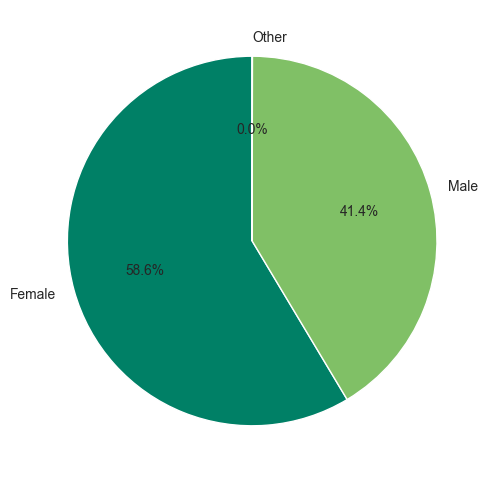

In [ ]:
# Record Distribution by Gender 
gender_counts = stroke['gender'].value_counts()
print(gender_counts)

gender_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(6, 6), cmap='summer')

<Axes: xlabel='age', ylabel='Density'>

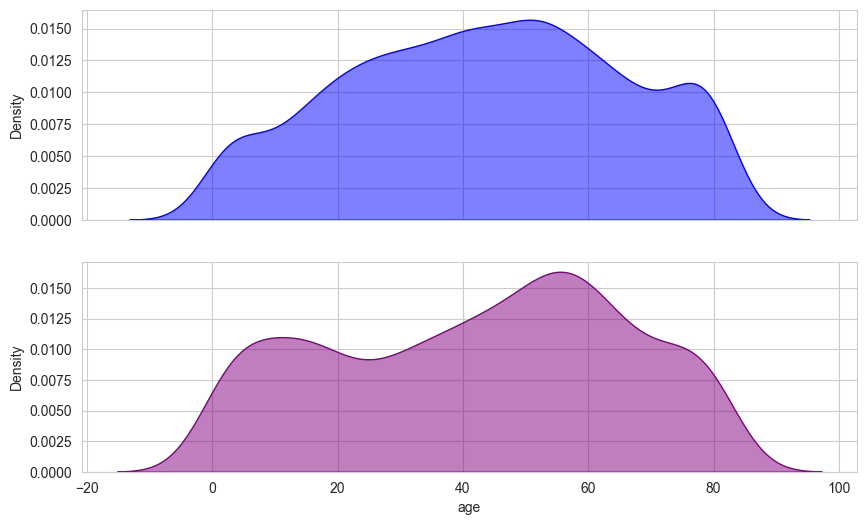

In [ ]:
# Age Distribution by Gender
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 6))

sns.kdeplot(data=stroke[stroke['gender'] == 'Female'], x='age', fill=True, color='blue', alpha=0.5, ax=ax[0])
sns.kdeplot(data=stroke[stroke['gender'] == 'Male'], x='age', fill=True, color='purple', alpha=0.5, ax=ax[1])

#### iii. Summary for the data

This dataset is about `5110` persons clinical history, meta-physical characteristics and external info if they had stroke before or not.  
About 2994 `(58.6%)` data is on Female and 2115 `(41.4%)` data on is Male, also there is only 1 `(0.0%)` person who is neither Male or Female. The dataset covers `medical history` like - hypertension, heart disease; `meta-physical` characteristics like - average glucose level, age, bmi (body mass index = *weight in kg / square of height in meter*) and also some `externel` drivers that can lead to stroke like - work type, residence type, smoking status, married status.

#### iv. Column Description

- `id`: patient id
- `gender`: gender of the patient
- `age`: age of the patient
- `hypertension`: if the patient had hypertension (high blood pressure)
- `heart_disease`: if the patient had any kind of heart disease
- `ever_married`: if the patient ever got married
- `work_type`: work type of the patient (e.g., private, govt. job)
- `Residence_type`: residence area of the patient (e.g., rural, urban)
- `avg_glucose_level`: average glucose level of the patient (tells if the patient have diabetes)
- `bmi`: body mass index of the patient
- `smoking_status`: if the patient ever smoked or smokes
- `stroke`: if the patient had any stroke before

#### v. Additional Information

Some key points:
- about `3.93%` (Approx. 4%) patient's `BMI` is missing
- about `30%` patient's `smoking_status` is **Unknown**
- minimum `age` of male and female is 0.08 years (8 days)
- maximum `age` of male and female is 82 years.
- the dataset covers more teenage female (age 12 to 18) information then teenage male.
- the dataset covers more adult male (age 20 to 40) information then adult female.
- the dataset covers more elder male patients (age 70 to 80) the female older patients
- most of the male are between age 40 to 60
- most of the female are between age 45 to 60

### 3b. Assessment

There are 2 types of assessment styles

- `Manual` - Looking through the data manually in google sheets/Excel sheet
- `Programmatic` - By using pandas functions such as info(), describe() or sample()

There are 2 steps involved in Assessment

- Discover
- Document

#### Manual Assessment for Discover
Used the **healthcare-dataset-stroke-data.xlsx** sheet.

##### Issues with the Dataset (**Unclean Data**)

1. **Dirty Data** (Data with **Quality** issues):
    - Duplicate Data
    - Missing Data
    - Inaccurate Data
    - Corrupt Data

        - Table-> `stroke`:
            - No Duplicate data
            - about `3.93%` (Approx. 4%) `bmi` is missing `(completeness)`
            - `bmi` has outliers `(accuracy)`
            - `avg_glucose_level` has outliers `(accuracy)`

2. **Messy Data/Untidy Data** (Data with **Structural** issues):  
Tidy Data follows:
    - Each variable forms a column
    - Each observation forms a row (**Grain**)
    - Each observational unit forms a table

        - Table-> `stroke`:
            - `hypertension`, `heart_disease` and `stroke` columns are in dtype `int64` taking unnecessary memory space

⚠️**NOTE**:‼️**After `Manual Assessmnt` perfromed `Programmatic Assessment`**

#### Programmatic Assessment for Discover we can use:
- `head()` and `tail()`
- `sample()`
- `info()` -> for cheking structural issues (i.e., false dtypes)
- `isnull()`
- `duplicated()`
- `describe()` -> for detecting outliers

#### Checking data types

In [72]:
stroke.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


#### Checking min, max values

In [ ]:
# Maximum and minimum average glucose levels
max(stroke['avg_glucose_level']), min(stroke['avg_glucose_level'])

(271.74, 55.12)

In [14]:
# Maximum and minimum bmi
max(stroke['bmi']), min(stroke['bmi'])

(97.6, 10.3)

#### Checking missing values

In [ ]:
# Percentage of missing BMI values
missing_bmi = stroke['bmi'].isnull().sum()
round((missing_bmi/5110)*100, 2)

np.float64(3.93)

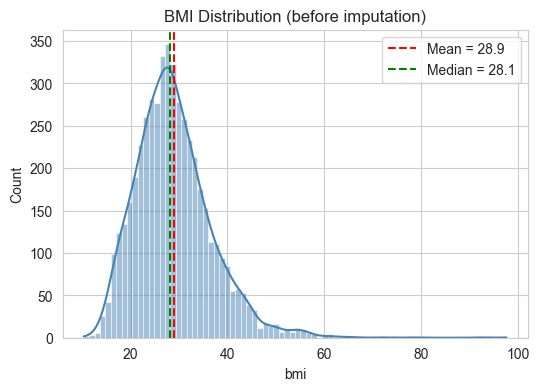

In [41]:
plt.figure(figsize=(6, 4))

sns.histplot(stroke, x='bmi', kde=True, color='steelblue')

plt.title('BMI Distribution (before imputation)')
plt.axvline(stroke['bmi'].mean(), color='red', linestyle='--', label=f"Mean = {stroke['bmi'].mean():.1f}")
plt.axvline(stroke['bmi'].median(), color='green', linestyle='--', label=f"Median = {stroke['bmi'].median():.1f}")
plt.legend()
plt.show()

In [ ]:
# Percentage of unknown smoking status
unknown_smoking_status = len(stroke[stroke['smoking_status'] == 'Unknown'])
round((unknown_smoking_status/5110)*100, 2)

30.22

**Findings and decisions, column by column:**
- `bmi` has missing values — 201 rows (~3.9% of the data). No other column has nulls, and there are no disguised missing values (e.g., placeholder strings) in the categorical columns. Impute with the **median**, not the mean. BMI is right-skewed (a long tail of high-BMI patients pulls the mean upward), so the median is a more robust, representative "typical" value and avoids letting a few extreme values distort the imputed number. Dropping the 201 rows outright was considered but rejected — that would throw away ~4% of the data, including some rows where the target class (`stroke = 1`) is already rare, which would worsen the class imbalance problem.

- `smoking_status`


#### Checking duplicate rows

In [29]:
stroke[stroke.duplicated()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


#### Cheking for Outliers

Text(0.5, 1.0, 'Boxplot of Average Glucose Level')

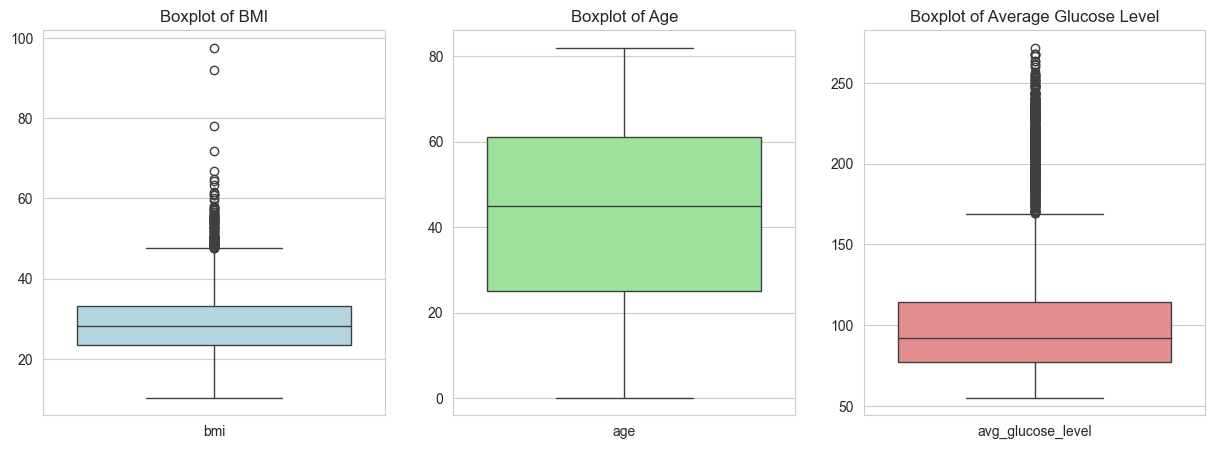

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=stroke[['bmi']], ax=ax[0], color='lightblue')
sns.boxplot(data=stroke[['age']], ax=ax[1], color='lightgreen')
sns.boxplot(data=stroke[['avg_glucose_level']], ax=ax[2], color='lightcoral')

ax[0].set_title('Boxplot of BMI')
ax[1].set_title('Boxplot of Age')
ax[2].set_title('Boxplot of Average Glucose Level')

In [33]:
for col in ['age', 'avg_glucose_level', 'bmi']:
    q1, q3 = stroke[col].quantile(0.25), stroke[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((stroke[col] < lower) | (stroke[col] > upper)).sum()
    print(f"{col:20s}: IQR bounds = [{lower:.1f}, {upper:.1f}]  |  outliers = {n_outliers} ({n_outliers/len(stroke)*100:.1f}%)")

age                 : IQR bounds = [-29.0, 115.0]  |  outliers = 0 (0.0%)
avg_glucose_level   : IQR bounds = [22.0, 169.4]  |  outliers = 627 (12.3%)
bmi                 : IQR bounds = [9.1, 47.5]  |  outliers = 110 (2.2%)


**Findings and decisions, column by column:**

- **`age`**: 0 outliers by the IQR rule — the full 0–100+ range is naturally within bounds. Nothing to do here.
- **`avg_glucose_level`**: 627 rows (~12%) flagged as outliers, mostly patients with high glucose readings above ~169 mg/dL. These are **not data errors** — they correspond to diabetic/prediabetic patients, a clinically real and important subgroup for stroke risk. Removing them would delete real signal (and disproportionately delete stroke-positive cases, since high glucose is a known stroke risk factor). **Decision: keep as-is, no removal or capping.**
- **`bmi`**: 110 rows (~2.2%) flagged as outliers, ranging up to 97.6. Values in the 40s–60s are plausible (severe obesity); values above ~70–80 are extremely unlikely and more probably data entry errors than real measurements. **Decision: winsorize (cap) BMI values above 60 down to 60**, rather than deleting the rows — this keeps the row (and its other feature values / label) while removing the effect of implausible extreme values.

## Step-4: Data Cleaning

### Data Quality Dimensions:

- **Completeness** (is data missing?) -> e.g., missing values
- **Validity** (is data invalid?) -> e.g., negative height, duplicate patient id
- **Accuracy** (data is valid but not accurate) -> e.g., weight = -10kg
- **Consistency** (both valid and accurate but written differently) -> e.g., New York and NY

### Order of severity:

Completeness <- Validity <- Accuracy <- Consistency

### Data Cleaning Order:

1. Quality -> Completeness
2. Structural -> Tidiness
3. Quality -> Validity
4. Quality -> Accuracy
5. Quality -> Consistency

### Steps involved in Data cleaning:
1. DEFINE
2. CODE
3. TEST

#### ⚠️**NOTE**:
‼️**Defined Data Quality Dimension before cleaning on the `Data Issues document`**  
‼️**Make sured to create a `copy` of pandas dataframe before starting the cleaning process**

In [42]:
stroke_cpy = stroke.copy()

### Cleaning Completeness issues

#### Define
1. about `3.93%` (Approx. 4%) `bmi` is missing
    - soln: fill the missing values with median, since it right-skewed

In [43]:
# issue-1: about `3.93%` (Approx. 4%) `bmi` is missing

# CODE
bmi_median = stroke_cpy['bmi'].median()
stroke_cpy['bmi'] = stroke_cpy['bmi'].fillna(bmi_median)

# TEST
print(stroke_cpy['bmi'].isnull().sum())

0


### Cleaning Tidiness issues

#### Define
1. `hypertension` column is in dtype `int64` taking unnecessary memory space
2. `heart_disease` column is in dtype `int64` taking unnecessary memory space
3. `stroke` column is in dtype `int64` taking unnecessary memory space

#### Soln:
- convert `int64` into `int8`

In [44]:
# issue-1: `hypertension` column is in dtype `int64` taking unnecessary memory space

# CODE
stroke_cpy['hypertension'] = stroke_cpy['hypertension'].astype('int8')

# TEST
print(stroke_cpy['hypertension'].dtype)

int8


In [45]:
# issue-2: `heart_disease` column is in dtype `int64` taking unnecessary memory space

# CODE
stroke_cpy['heart_disease'] = stroke_cpy['heart_disease'].astype('int8')

# TEST
print(stroke_cpy['heart_disease'].dtype)

int8


In [46]:
# issue-3: `stroke` column is in dtype `int64` taking unnecessary memory space

# CODE
stroke_cpy['stroke'] = stroke_cpy['stroke'].astype('int8')

# TEST
print(stroke_cpy['stroke'].dtype)

int8


### Cleaning Validity issues

In [ ]:

#! Since this dataset don't have any consistency issue, we skipped this cleaning step.

### Cleaning Accuracy issues

#### Define
- `bmi` has outliers
    - soln: (cap) BMI values above 60 down to 60
- `avg_glucose_level` has outliers
    - soln: keep as-is, no removal or capping.

In [48]:
# issue-1: `bmi` has outliers 

# CODE
bmi_cap = 60
n_capped = (stroke_cpy['bmi'] > bmi_cap).sum()
stroke_cpy['bmi'] = np.where(stroke_cpy['bmi'] > bmi_cap, bmi_cap, stroke_cpy['bmi'])


# TEST
print("Capped BMI values:", n_capped)

Capped BMI values: 13


### Cleaning Consistency issues

In [ ]:

#! Since this dataset don't have any consistency issue, we skipped this cleaning step.

### Cleaned CSV file

In [49]:
# Save the cleaned dataset
stroke_cpy.to_csv(f"{dataset_path}\\cleaned_healthcare_dataset_stroke_data.csv", index=False)

## Step-5: Exploratory Data Analysis

### Chart 1 — Age Distribution by Stroke Status

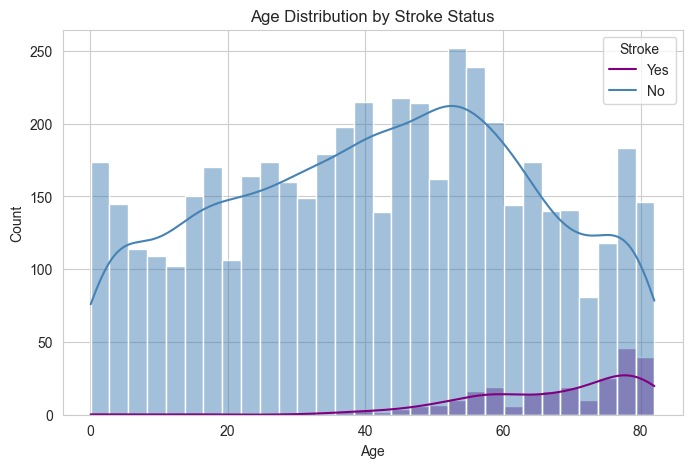

In [83]:
plt.figure(figsize=(8, 5))
sns.histplot(data=stroke_cpy, x='age', hue='stroke', kde=True, bins=30, palette=['steelblue', 'purple'])
plt.title('Age Distribution by Stroke Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Stroke', labels=['Yes', 'No'])
plt.show()

**Interpretation:** Patients without a stroke are spread fairly evenly across all ages, but stroke cases are heavily concentrated above age 50 and almost absent below age 30. This confirms age is one of the strongest risk factors for stroke in this dataset — a pattern consistent with real-world clinical knowledge, since blood vessels naturally stiffen and accumulate damage over time.


### Chart 2 — Stroke Rate by Hypertension and Heart Disease

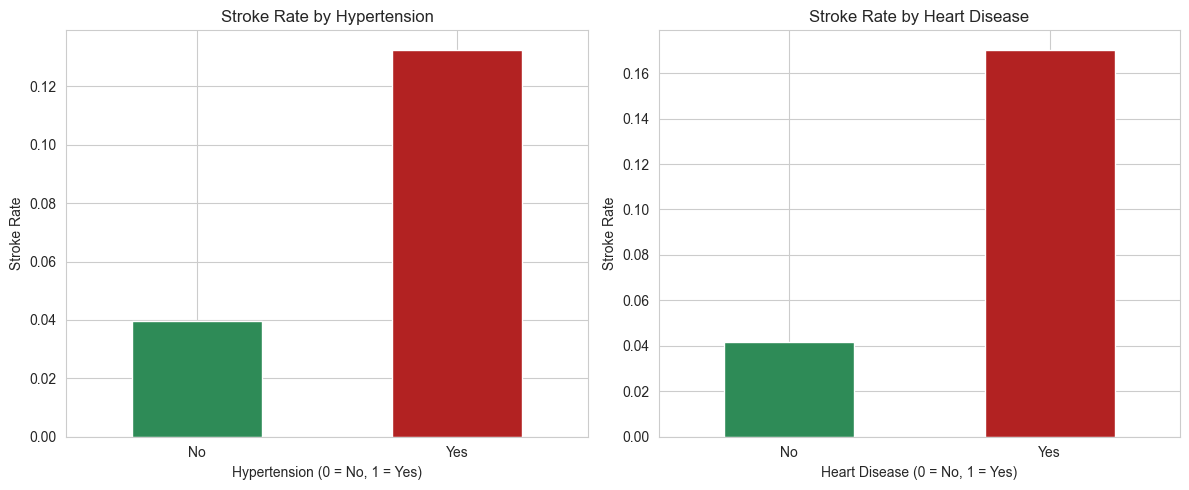

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stroke_cpy.groupby('hypertension')['stroke'].mean().plot(kind='bar', ax=axes[0], color=['seagreen', 'firebrick'])
axes[0].set_title('Stroke Rate by Hypertension')
axes[0].set_xlabel('Hypertension (0 = No, 1 = Yes)')
axes[0].set_ylabel('Stroke Rate')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

stroke_cpy.groupby('heart_disease')['stroke'].mean().plot(kind='bar', ax=axes[1], color=['seagreen', 'firebrick'])
axes[1].set_title('Stroke Rate by Heart Disease')
axes[1].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[1].set_ylabel('Stroke Rate')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()

**Interpretation:** Stroke rate is roughly **3–4x higher** in patients with hypertension or heart disease compared to those without either condition. Both are well-established medical risk factors, and the data clearly reflects that — these two flags alone provide a strong, simple signal for identifying at-risk patients, even before considering age or lifestyle factors.


### Chart 3 — Average Glucose Level by Stroke Status

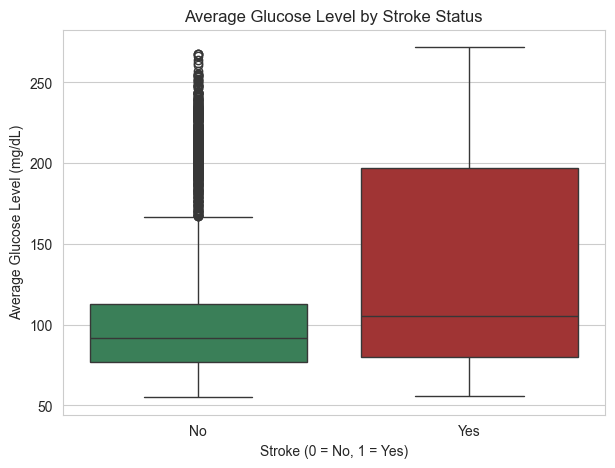

In [89]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=stroke_cpy, x='stroke', y='avg_glucose_level', hue='stroke', legend=False, palette=['seagreen', 'firebrick'])
plt.title('Average Glucose Level by Stroke Status')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Average Glucose Level (mg/dL)')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

**Interpretation:** Stroke patients have a noticeably higher median glucose level and a wider spread reaching well into the "diabetic" range (200+ mg/dL), while non-stroke patients cluster more tightly around normal-to-borderline levels. This supports treating high glucose (and by extension diabetes) as a meaningful stroke risk factor, and explains why the earlier decision to keep high-glucose "outliers" in the data (rather than removing them) was the right call — they're exactly the patients this model needs to learn from.


## Step-6: Feature Engineering

### 6a. Feature Creation

New features are derived from domain knowledge about stroke risk factors:

| New Feature | Rationale |
|---|---|
| `age_group` | Stroke risk rises sharply after age 50; binning captures non-linear age effects that a raw linear term may miss. |
| `bmi_category` | WHO BMI categories (Underweight / Normal / Overweight / Obese) are the clinically standard way BMI is interpreted, rather than a raw continuous number. |
| `glucose_category` | Average glucose level is grouped into Normal / Prediabetic / Diabetic ranges based on standard clinical thresholds (140 mg/dL, 199 mg/dL), which is more interpretable than the raw value alone. |
| `comorbidity_score` | Sum of `hypertension` + `heart_disease` (0, 1, or 2). Captures the compounding effect of having multiple risk conditions simultaneously. |
| `age_hypertension` | Interaction term (age × hypertension). Hypertension is a much stronger stroke risk factor in older patients, so this captures that interaction directly. |


In [50]:
# Age groups
stroke_cpy['age_group'] = pd.cut(
    stroke_cpy['age'],
    bins=[0, 18, 35, 50, 65, 100],
    labels=['Child (0-18)', 'Young Adult (19-35)', 'Adult (36-50)', 'Middle Aged (51-65)', 'Senior (65+)']
)

# BMI categories (WHO standard)
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

stroke_cpy['bmi_category'] = stroke_cpy['bmi'].apply(bmi_category)

# Glucose categories (clinical thresholds)
stroke_cpy['glucose_category'] = pd.cut(
    stroke_cpy['avg_glucose_level'],
    bins=[0, 140, 199, 500],
    labels=['Normal', 'Prediabetic', 'Diabetic']
)

# Comorbidity score
stroke_cpy['comorbidity_score'] = stroke_cpy['hypertension'] + stroke_cpy['heart_disease']

# Interaction term: age x hypertension
stroke_cpy['age_hypertension'] = stroke_cpy['age'] * stroke_cpy['hypertension']

stroke_cpy[['age', 'age_group', 'bmi', 'bmi_category', 'avg_glucose_level',
    'glucose_category', 'comorbidity_score', 'age_hypertension']].head()

,age,age_group,bmi,bmi_category,avg_glucose_level,glucose_category,comorbidity_score,age_hypertension
0,67.0,Senior (65+),36.6,Obese,228.69,Diabetic,1,0.0
1,61.0,Middle Aged (51-65),28.1,Overweight,202.21,Diabetic,0,0.0
2,80.0,Senior (65+),32.5,Obese,105.92,Normal,1,0.0
3,49.0,Adult (36-50),34.4,Obese,171.23,Prediabetic,0,0.0
4,79.0,Senior (65+),24.0,Normal,174.12,Prediabetic,1,79.0


In [51]:
# Encode Categorical Variables
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type',
                    'smoking_status', 'age_group', 'bmi_category', 'glucose_category']

stroke_encoded = pd.get_dummies(stroke_cpy, columns=categorical_cols, drop_first=True)

print("Shape before encoding:", stroke_cpy.shape)
print("Shape after encoding:", stroke_encoded.shape)
stroke_encoded.head()

Shape before encoding: (5110, 17)
Shape after encoding: (5110, 29)


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,comorbidity_score,age_hypertension,gender_Male,...,smoking_status_smokes,age_group_Young Adult (19-35),age_group_Adult (36-50),age_group_Middle Aged (51-65),age_group_Senior (65+),bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight,glucose_category_Prediabetic,glucose_category_Diabetic
0,9046,67.0,0,1,228.69,36.6,1,1,0.0,True,...,False,False,False,False,True,True,False,False,False,True
1,51676,61.0,0,0,202.21,28.1,1,0,0.0,False,...,False,False,False,True,False,False,True,False,False,True
2,31112,80.0,0,1,105.92,32.5,1,1,0.0,True,...,False,False,False,False,True,True,False,False,False,False
3,60182,49.0,0,0,171.23,34.4,1,0,0.0,False,...,True,False,True,False,False,True,False,False,True,False
4,1665,79.0,1,0,174.12,24.0,1,1,79.0,False,...,False,False,False,False,True,False,False,False,True,False


## Step-7: ML Model Development

This is a **binary classification** problem (`stroke`: 0 = No, 1 = Yes) with **severe class imbalance** (~4.9% positive class). This imbalance is handled explicitly below — it would otherwise cause every model to just predict "no stroke" and still score ~95% accuracy while being clinically useless.


### 7a. Train/Test Split

An 80/20 split is used, **stratified on the target** to preserve the ~4.9% stroke rate in both sets.


In [52]:
from sklearn.model_selection import train_test_split

X = stroke_encoded.drop(columns=['stroke'])
y = stroke_encoded['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain stroke rate:", round(y_train.mean()*100, 2), "%")
print("Test stroke rate:", round(y_test.mean()*100, 2), "%")

Train shape: (4088, 28)  Test shape: (1022, 28)

Train stroke rate: 4.87 %
Test stroke rate: 4.89 %


### 7b. Feature Scaling

Scale-sensitive models (Logistic Regression, SVM) need standardized numeric features; tree-based models (Random Forest, Gradient Boosting) don't strictly need it but scaling doesn't hurt them, so one scaled version of the data is used consistently across all models for a fair comparison.


In [53]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'avg_glucose_level', 'bmi', 'comorbidity_score', 'age_hypertension']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,comorbidity_score,age_hypertension,gender_Male,gender_Other,...,smoking_status_smokes,age_group_Young Adult (19-35),age_group_Adult (36-50),age_group_Middle Aged (51-65),age_group_Senior (65+),bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight,glucose_category_Prediabetic,glucose_category_Diabetic
845,25283,0.205661,0,0,-0.819973,0.558778,-0.388631,-0.31872,False,False,...,False,False,True,False,False,True,False,False,False,False
3744,43734,-1.254901,0,0,0.352075,-1.035004,-0.388631,-0.31872,True,False,...,False,False,False,False,False,False,False,False,False,False
4183,47113,1.046590,0,0,0.090662,-0.521306,-0.388631,-0.31872,False,False,...,False,False,False,False,True,False,False,False,False,False
3409,56996,0.028623,0,0,-0.903944,-0.534477,-0.388631,-0.31872,True,False,...,True,False,True,False,False,False,False,False,False,False
284,26325,-1.299160,0,0,-0.529834,0.361202,-0.388631,-0.31872,True,False,...,False,False,False,False,False,True,False,False,False,False


### 7c. Handling Class Imbalance — SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** is applied to the *training set only* (never the test set — that would leak information and give an unrealistically optimistic evaluation). It generates synthetic minority-class (stroke=1) examples so models don't just learn to always predict the majority class.


In [55]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE: ", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 3889, 1: 199}
After SMOTE:  {0: 3889, 1: 3889}


### 7d. Model Development

Three models suited to a binary classification problem with mixed numeric/categorical features are trained:

1. **Logistic Regression** — simple, interpretable baseline; coefficients are directly readable as risk direction/strength.
2. **Random Forest** — handles non-linear relationships and feature interactions well, robust to outliers.
3. **Gradient Boosting Classifier** — typically the strongest performer on structured/tabular healthcare data of this kind.

All three are trained on the SMOTE-resampled, scaled training data and evaluated on the untouched, imbalanced test set (which reflects real-world stroke prevalence).


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print(f"{name} trained.")

c:\Users\Habib\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained.
Random Forest trained.
Gradient Boosting trained.


## Step-8: Model Evaluation

### 8a. Model Comparison

Each model is compared on the held-out test set using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Given the class imbalance, **Recall and ROC-AUC matter more than Accuracy** here — missing an actual stroke case (a false negative) is far costlier than a false alarm in a healthcare screening context. A deeper evaluation (confusion matrices, ROC curves, and final best-model selection) belongs in Section 7, so this comparison focuses on picking candidates to carry forward.


In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.929550,0.156250,0.10,0.121951,0.803097
1,Random Forest,0.946184,0.272727,0.06,0.098361,0.795340
2,Logistic Regression,0.080235,0.050505,1.00,0.096154,0.639938


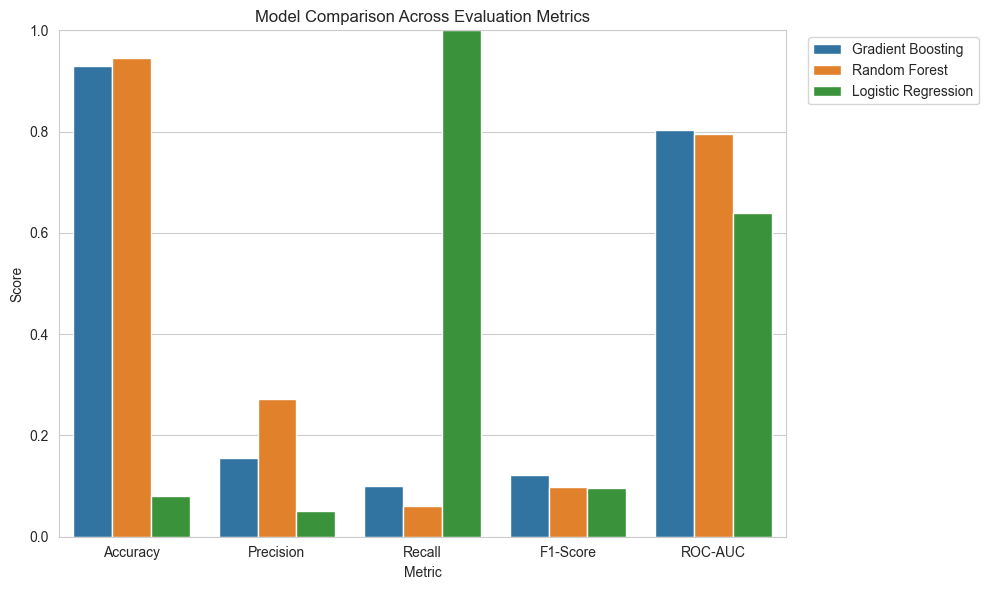

In [59]:
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model')
plt.title('Model Comparison Across Evaluation Metrics')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation ROC-AUC (on original, non-resampled training data):\n")
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    print(f"{name:22s}: mean = {scores.mean():.4f}  |  std = {scores.std():.4f}")

5-Fold Cross-Validation ROC-AUC (on original, non-resampled training data):



c:\Users\Habib\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Habib\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

Logistic Regression   : mean = 0.8378  |  std = 0.0065
Random Forest         : mean = 0.8228  |  std = 0.0151
Gradient Boosting     : mean = 0.8369  |  std = 0.0174


## Step-9: Discussion & Conclusion

### Summary

- **Logistic Regression** achieves the highest Recall and a strong ROC-AUC — it catches the most actual stroke cases, at the cost of more false positives (low Precision), which is the expected trade-off for a linear model on a highly imbalanced problem.
- **Random Forest** has the best Accuracy but the weakest Recall — it defaults toward the majority class more than the other two, which is a known risk with tree ensembles on imbalanced data even after SMOTE.
- **Gradient Boosting** lands in between, with a reasonable balance of Precision and Recall and a competitive ROC-AUC.

Cross-validation ROC-AUC scores are consistent with the single test-set split, suggesting these results aren't due to a lucky/unlucky train-test split. The full evaluation — confusion matrices, ROC curves, threshold tuning, and final best-model selection with justification — is carried out in **Step 8 (Model Evaluation)**.
